# AI-Driven Financial Fraud Detection, Risk Scoring & Explainable Decision Support

**Complex Computing Problem (CCP)** - Data Science & Visualization Lab, BS AI (7th Semester)

This notebook implements **Tasks 2-9** of the CCP on mobile-money transaction data
(PaySim schema): exploratory analysis, behavioral feature engineering, imbalance
handling, supervised + deep models, explainability (SHAP/LIME), a dynamic risk-scoring
engine, unsupervised anomaly discovery, and a four-view BI dashboard.

Tasks 1, 10, 11 and 12 (business understanding, scalability, literature review,
critical evaluation) are in the accompanying `report/report.pdf`.

> **Stack note.** This is the lean (no-TensorFlow) build: the ANN and Autoencoder
> are implemented with scikit-learn (`MLPClassifier` / `MLPRegressor`). Heavy steps
> (deep models, SHAP, LIME, DBSCAN/LOF) run on a stratified subsample for tractability.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
# Render inline inside Jupyter (so plots appear in the notebook) but stay headless
# when run as a plain script.
try:
    _IN_NOTEBOOK = get_ipython() is not None        # type: ignore[name-defined]
except NameError:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
if _IN_NOTEBOOK:
    get_ipython().run_line_magic("matplotlib", "inline")   # type: ignore[name-defined]

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# --- paths (work both as a script in src/ and as a notebook in notebooks/) ---
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name in ("src", "notebooks") else HERE
SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
PROC_DIR = PROJECT_ROOT / "data" / "processed"
for d in (FIG_DIR, MODEL_DIR, PROC_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))
from data_loader import load_paysim   # noqa: E402

# Working-set sizes (keep runtime bounded regardless of data source)
MODEL_SAMPLE = 200_000      # stratified sample used for modeling
HEAVY_SAMPLE = 30_000       # SHAP / LIME / DBSCAN / LOF subsample

def savefig(name: str):
    """Save figure to outputs/figures; also render it inline when in a notebook."""
    path = FIG_DIR / name
    plt.savefig(path)
    print(f"  saved figure -> {path.name}")
    if _IN_NOTEBOOK:
        plt.show()
    plt.close()

print("Environment ready. Figures ->", FIG_DIR)

Environment ready. Figures -> C:\Users\qubit\OneDrive\Documents\Automations\Nexis\projects\fraud-detection-ccp\outputs\figures


## Task 2 - Data Acquisition & Exploratory Data Analysis

We load the PaySim mobile-money dataset (real public mirror if reachable, otherwise a
reproducible synthetic dataset with the same schema and fraud signal). PaySim records
five transaction types; **fraud occurs only in `TRANSFER` and `CASH_OUT`**, where an
attacker drains an account and cashes out through a mule.

In [2]:
t0 = time.time()
df, DATA_SOURCE = load_paysim()
print(f"Data source : {DATA_SOURCE}")
print(f"Loaded shape: {df.shape}  in {time.time()-t0:.1f}s")
df.head()

[data_loader] Loading cached file: C:\Users\qubit\OneDrive\Documents\Automations\Nexis\projects\fraud-detection-ccp\data\raw\paysim.csv


Data source : synthetic
Loaded shape: (1000000, 11)  in 1.7s


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,684,PAYMENT,645.94,C6376380,129794.76,129132.95,M5122134,0.00,0.00,0,0
1,431,CASH_OUT,1090.57,C8476679,3152.91,2120.83,C2998852,5356.07,6424.08,0,0
2,263,PAYMENT,716.56,C9724095,5220.98,4492.49,M6297504,0.00,0.00,0,0
3,221,CASH_OUT,30972.14,C5671994,2843.92,3.78,C9627429,2603.77,33615.77,0,0
4,277,CASH_OUT,5332.18,C7420196,16318.23,10981.66,C2398937,145642.77,150949.86,0,0


In [3]:
# --- profiling: dtypes, memory, basic info ---
print("=== Schema & dtypes ===")
print(df.dtypes)
print("\n=== Numeric summary ===")
display_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
                "oldbalanceDest", "newbalanceDest"]
print(df[display_cols].describe().round(2).T)

=== Schema & dtypes ===
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

=== Numeric summary ===


                    count      mean       std    min      25%      50%  \
amount          1000000.0  12079.77  32084.17   2.56  1571.99  4190.17   
oldbalanceOrg   1000000.0  18899.13  40537.56  20.79  3379.00  8115.57   
newbalanceOrig  1000000.0  13703.48  39125.40   0.00    10.38  2485.00   
oldbalanceDest  1000000.0   8642.16  27017.02   0.00     0.00  1834.00   
newbalanceDest  1000000.0  17974.71  41643.14   0.00     0.00  6647.46   

                     75%         max  
amount          11201.92  3055263.15  
oldbalanceOrg   19536.40  8083969.83  
newbalanceOrig  12876.24  8079268.09  
oldbalanceDest   7528.92  3530613.86  
newbalanceDest  19875.77  3648437.69  


In [4]:
# --- missing values & duplicates ---
missing = df.isna().sum()
dupes = df.duplicated().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "  none")
print(f"\nExact duplicate rows: {dupes:,} ({dupes/len(df)*100:.3f}%)")

Missing values per column:
  none

Exact duplicate rows: 0 (0.000%)


Legitimate: 998,000
Fraud     : 2,000
Fraud rate: 0.2000%   (imbalance ratio ~ 1:499)


  saved figure -> t2_class_imbalance.png


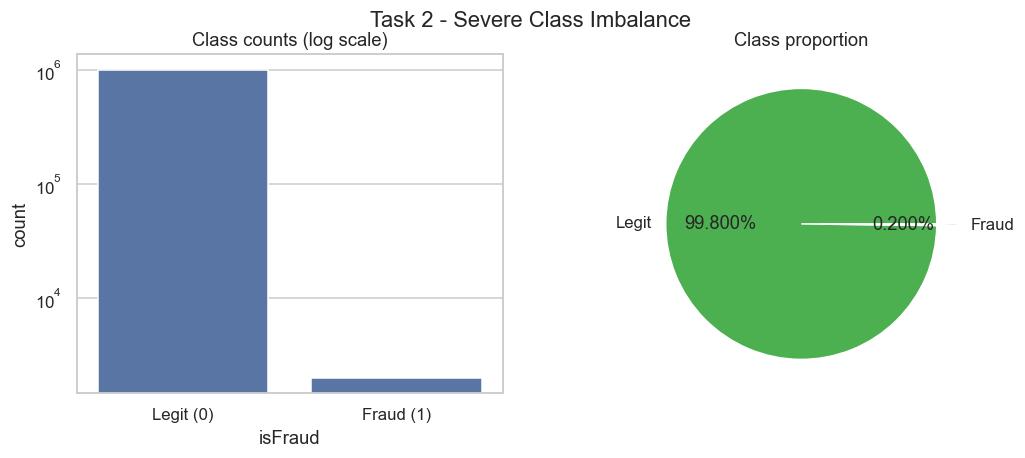

In [5]:
# --- class imbalance ---
fraud_rate = df["isFraud"].mean()
counts = df["isFraud"].value_counts()
print(f"Legitimate: {counts.get(0,0):,}")
print(f"Fraud     : {counts.get(1,0):,}")
print(f"Fraud rate: {fraud_rate*100:.4f}%   (imbalance ratio ~ 1:{int((1-fraud_rate)/max(fraud_rate,1e-9))})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="isFraud", data=df, ax=ax[0])
ax[0].set_title("Class counts (log scale)")
ax[0].set_yscale("log")
ax[0].set_xticklabels(["Legit (0)", "Fraud (1)"])
df["isFraud"].value_counts(normalize=True).plot.pie(
    autopct="%.3f%%", labels=["Legit", "Fraud"], ax=ax[1],
    colors=["#4caf50", "#e53935"], explode=[0, 0.15])
ax[1].set_ylabel("")
ax[1].set_title("Class proportion")
plt.suptitle("Task 2 - Severe Class Imbalance")
savefig("t2_class_imbalance.png")

  saved figure -> t2_type_distribution.png


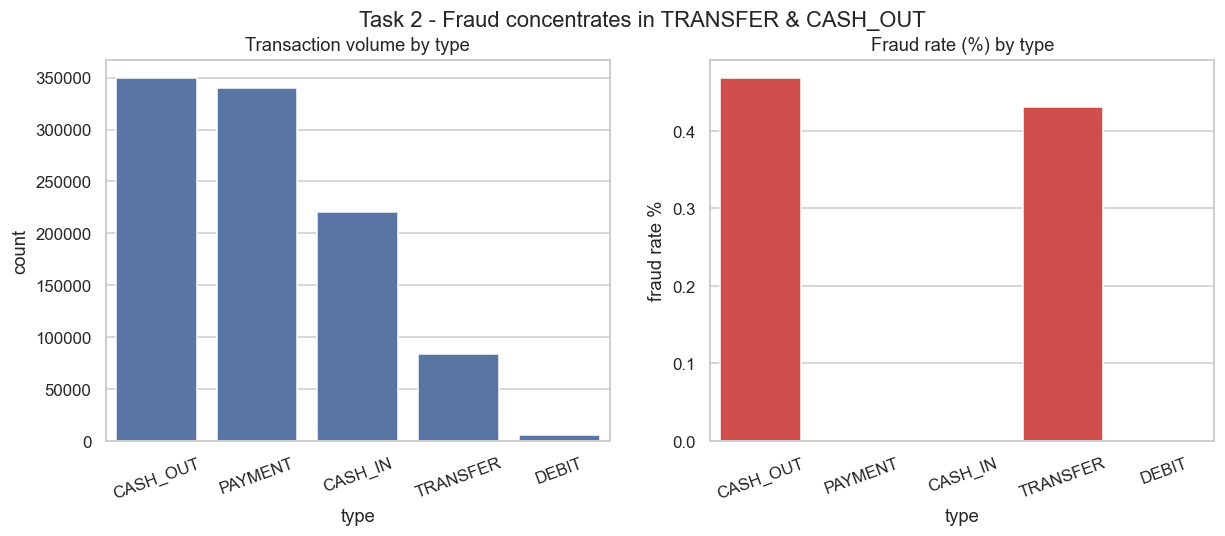

type
CASH_OUT    0.4683
PAYMENT     0.0000
CASH_IN     0.0000
TRANSFER    0.4304
DEBIT       0.0000
Name: isFraud, dtype: float64


In [6]:
# --- transaction type distribution & fraud rate by type ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
order = df["type"].value_counts().index
sns.countplot(x="type", data=df, order=order, ax=ax[0])
ax[0].set_title("Transaction volume by type")
ax[0].tick_params(axis="x", rotation=20)

fraud_by_type = df.groupby("type")["isFraud"].mean().reindex(order) * 100
sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values, ax=ax[1], color="#e53935")
ax[1].set_title("Fraud rate (%) by type")
ax[1].set_ylabel("fraud rate %")
ax[1].tick_params(axis="x", rotation=20)
plt.suptitle("Task 2 - Fraud concentrates in TRANSFER & CASH_OUT")
savefig("t2_type_distribution.png")
print(fraud_by_type.round(4))

  saved figure -> t2_amount_distribution.png


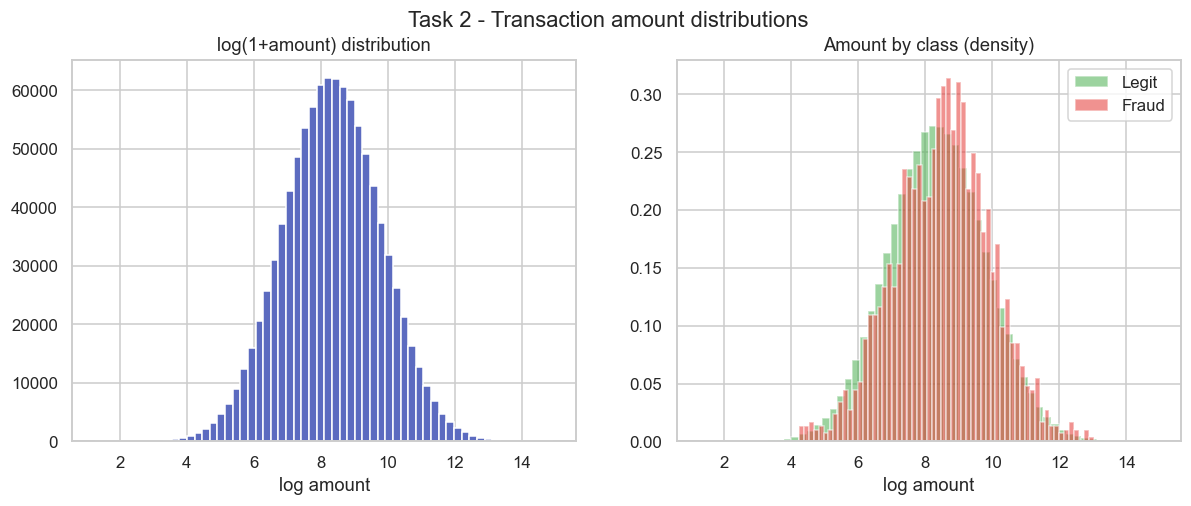

In [7]:
# --- amount distribution (overall vs fraud) ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(np.log1p(df["amount"]), bins=60, color="#5c6bc0")
ax[0].set_title("log(1+amount) distribution")
ax[0].set_xlabel("log amount")
for label, sub, c in [("Legit", df[df.isFraud == 0], "#4caf50"),
                      ("Fraud", df[df.isFraud == 1], "#e53935")]:
    ax[1].hist(np.log1p(sub["amount"]), bins=60, alpha=0.55, label=label, color=c, density=True)
ax[1].set_title("Amount by class (density)")
ax[1].set_xlabel("log amount")
ax[1].legend()
plt.suptitle("Task 2 - Transaction amount distributions")
savefig("t2_amount_distribution.png")

Amount IQR upper fence: 25,647
High-amount outliers  : 106,749 (10.67%)
Fraud rate among outliers: 0.231%


  saved figure -> t2_amount_outliers.png


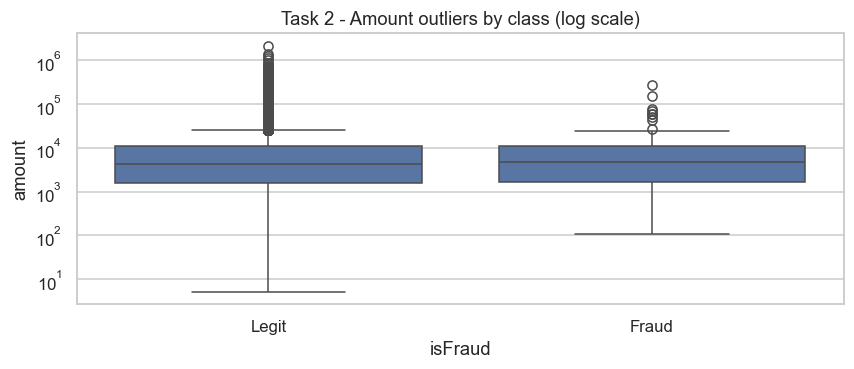

In [8]:
# --- outlier analysis (IQR) on amount ---
q1, q3 = df["amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
outliers = (df["amount"] > upper).sum()
print(f"Amount IQR upper fence: {upper:,.0f}")
print(f"High-amount outliers  : {outliers:,} ({outliers/len(df)*100:.2f}%)")
print(f"Fraud rate among outliers: {df.loc[df.amount > upper, 'isFraud'].mean()*100:.3f}%")

fig, ax = plt.subplots(figsize=(9, 3.2))
sns.boxplot(x="isFraud", y="amount", data=df.sample(min(50_000, len(df)), random_state=RANDOM_STATE),
            ax=ax, showfliers=True)
ax.set_yscale("log")
ax.set_xticklabels(["Legit", "Fraud"])
ax.set_title("Task 2 - Amount outliers by class (log scale)")
savefig("t2_amount_outliers.png")

  saved figure -> t2_correlation_raw.png


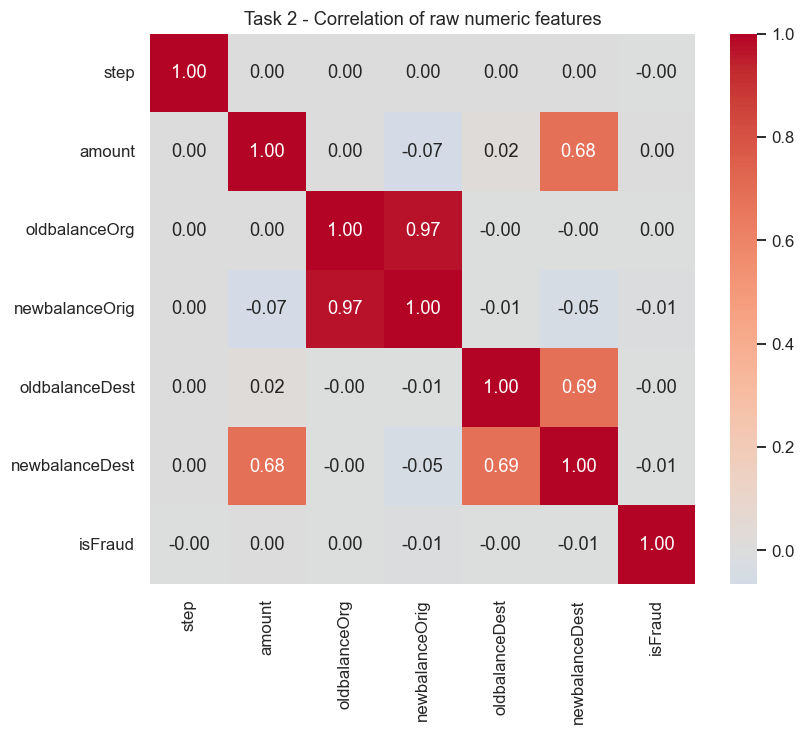

In [9]:
# --- correlation heatmap (numeric raw features) ---
num_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest", "isFraud"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Task 2 - Correlation of raw numeric features")
savefig("t2_correlation_raw.png")

**EDA takeaways.** The data is extremely imbalanced (fraud well under 1%), fraud is
confined to `TRANSFER`/`CASH_OUT`, fraudulent transactions skew to large amounts, and
raw balance columns carry weak linear correlation with the label - motivating the
engineered *balance-error* features below.

## Task 3 - Feature Engineering & Data Preparation

We derive **behavioral features** that encode the mechanics of mobile-money fraud:
balance-error terms (the ledger should balance for a legitimate debit/credit),
amount-to-balance ratios, merchant flags, account-draining flags, and time-of-day.
Then we one-hot encode `type`, scale numerics, run mutual-information feature
selection, and fit a PCA for visualization.

In [10]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()
    # ledger balance errors (≈0 for legitimate transactions)
    d["errorBalanceOrig"] = d["oldbalanceOrg"] - d["amount"] - d["newbalanceOrig"]
    d["errorBalanceDest"] = d["oldbalanceDest"] + d["amount"] - d["newbalanceDest"]
    # amount relative to available balance
    d["amount_to_oldOrg"] = d["amount"] / (d["oldbalanceOrg"] + 1.0)
    d["amount_to_oldDest"] = d["amount"] / (d["oldbalanceDest"] + 1.0)
    # account-draining signal
    d["orig_zeroed"] = ((d["oldbalanceOrg"] > 0) & (d["newbalanceOrig"] == 0)).astype(int)
    d["dest_was_empty"] = (d["oldbalanceDest"] == 0).astype(int)
    # merchant destination (PaySim merchants start with 'M')
    d["is_merchant_dest"] = d["nameDest"].astype(str).str.startswith("M").astype(int)
    # temporal
    d["hour"] = d["step"] % 24
    d["day"] = d["step"] // 24
    # one-hot encode transaction type
    d = pd.get_dummies(d, columns=["type"], prefix="type")
    type_cols = [c for c in d.columns if c.startswith("type_")]
    d[type_cols] = d[type_cols].astype(int)
    return d

df_fe = engineer_features(df)

FEATURES = [
    "step", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "errorBalanceOrig", "errorBalanceDest",
    "amount_to_oldOrg", "amount_to_oldDest",
    "orig_zeroed", "dest_was_empty", "is_merchant_dest", "hour",
] + [c for c in df_fe.columns if c.startswith("type_")]
TARGET = "isFraud"

print(f"Engineered feature count: {len(FEATURES)}")
print(FEATURES)

Engineered feature count: 19
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'amount_to_oldOrg', 'amount_to_oldDest', 'orig_zeroed', 'dest_was_empty', 'is_merchant_dest', 'hour', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


  saved figure -> t3_mutual_information.png


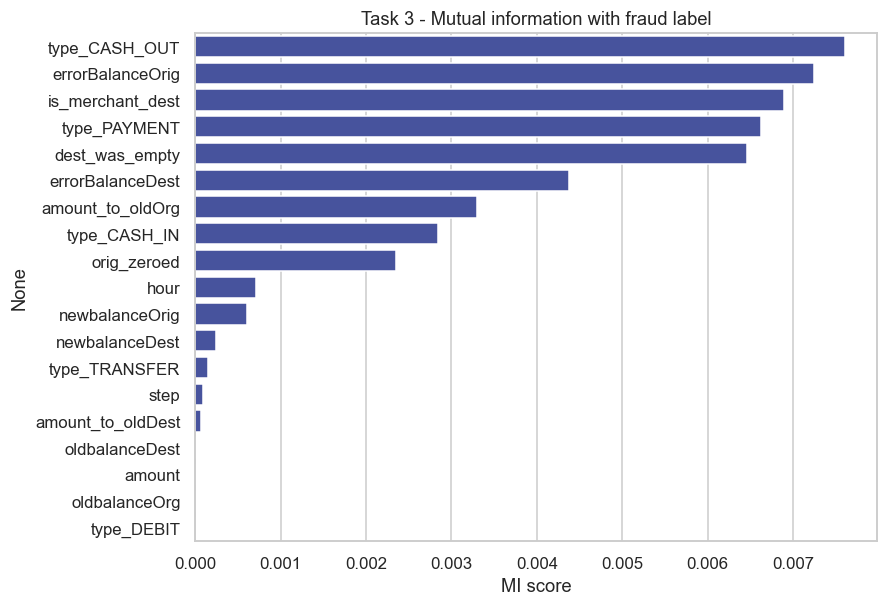

type_CASH_OUT        0.0076
errorBalanceOrig     0.0072
is_merchant_dest     0.0069
type_PAYMENT         0.0066
dest_was_empty       0.0065
errorBalanceDest     0.0044
amount_to_oldOrg     0.0033
type_CASH_IN         0.0028
orig_zeroed          0.0024
hour                 0.0007
newbalanceOrig       0.0006
newbalanceDest       0.0002
type_TRANSFER        0.0001
step                 0.0001
amount_to_oldDest    0.0001
oldbalanceDest       0.0000
amount               0.0000
oldbalanceOrg        0.0000
type_DEBIT           0.0000
dtype: float64


In [11]:
# --- mutual-information feature selection (on a sample for speed) ---
from sklearn.feature_selection import mutual_info_classif

mi_sample = df_fe.sample(min(80_000, len(df_fe)), random_state=RANDOM_STATE)
mi = mutual_info_classif(mi_sample[FEATURES], mi_sample[TARGET],
                         discrete_features=False, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, ax=ax, color="#3949ab")
ax.set_title("Task 3 - Mutual information with fraud label")
ax.set_xlabel("MI score")
savefig("t3_mutual_information.png")
print(mi_series.round(4))

In [12]:
# --- stratified working sample + train/test split ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if len(df_fe) > MODEL_SAMPLE:
    work, _ = train_test_split(df_fe, train_size=MODEL_SAMPLE,
                               stratify=df_fe[TARGET], random_state=RANDOM_STATE)
else:
    work = df_fe
print(f"Working set: {work.shape}, fraud: {int(work[TARGET].sum())} "
      f"({work[TARGET].mean()*100:.3f}%)")

X = work[FEATURES].astype(float)
y = work[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Train fraud: {y_train.sum()}   Test fraud: {y_test.sum()}")

Working set: (200000, 24), fraud: 400 (0.200%)
Train: (150000, 19)  Test: (50000, 19)
Train fraud: 300   Test fraud: 100


  saved figure -> t3_pca_projection.png


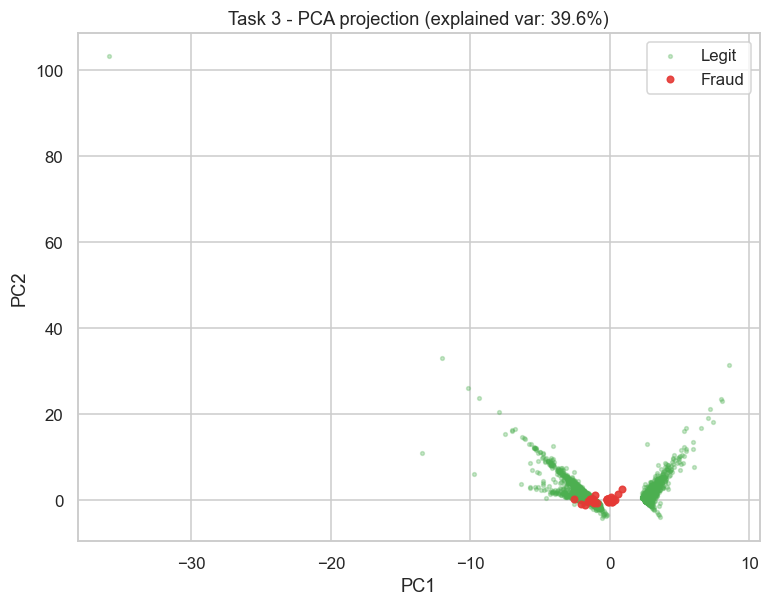

In [13]:
# --- PCA for visualization (2D projection of scaled features) ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
viz_idx = X_train_s.sample(min(15_000, len(X_train_s)), random_state=RANDOM_STATE).index
pcs = pca.fit_transform(X_train_s.loc[viz_idx])
yviz = y_train.loc[viz_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pcs[yviz == 0, 0], pcs[yviz == 0, 1], s=6, alpha=0.3, label="Legit", color="#4caf50")
ax.scatter(pcs[yviz == 1, 0], pcs[yviz == 1, 1], s=18, alpha=0.9, label="Fraud", color="#e53935")
ax.set_title(f"Task 3 - PCA projection (explained var: "
             f"{pca.explained_variance_ratio_.sum()*100:.1f}%)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()
savefig("t3_pca_projection.png")

## Task 4 - Handling Highly Imbalanced Data

We compare five resampling strategies - **Random Oversampling, Random Undersampling,
SMOTE, ADASYN, and a hybrid (SMOTEENN)** - by training the same classifier
(Random Forest) on each rebalanced training set and scoring on the untouched test set.
Because fraud detection cares about catching the minority class, we rank on
**PR-AUC and recall**, not accuracy.

In [14]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)

samplers = {
    "None (class_weight)": None,
    "RandomOverSampler": RandomOverSampler(random_state=RANDOM_STATE),
    "RandomUnderSampler": RandomUnderSampler(random_state=RANDOM_STATE),
    "SMOTE": SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    "ADASYN": ADASYN(random_state=RANDOM_STATE),
    "SMOTEENN (hybrid)": SMOTEENN(random_state=RANDOM_STATE),
}

imb_rows = []
for name, sampler in samplers.items():
    if sampler is None:
        Xr, yr = X_train_s, y_train
        clf = RandomForestClassifier(n_estimators=120, max_depth=12,
                                      class_weight="balanced",
                                      n_jobs=-1, random_state=RANDOM_STATE)
    else:
        Xr, yr = sampler.fit_resample(X_train_s, y_train)
        clf = RandomForestClassifier(n_estimators=120, max_depth=12,
                                      n_jobs=-1, random_state=RANDOM_STATE)
    clf.fit(Xr, yr)
    proba = clf.predict_proba(X_test_s)[:, 1]
    pred = (proba >= 0.5).astype(int)
    imb_rows.append({
        "Strategy": name,
        "Train size": len(yr),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
    })
    print(f"  {name:22s} -> PR-AUC {imb_rows[-1]['PR-AUC']:.3f}  Recall {imb_rows[-1]['Recall']:.3f}")

imb_df = pd.DataFrame(imb_rows).set_index("Strategy").round(4)
imb_df.to_csv(PROC_DIR / "imbalance_comparison.csv")
imb_df

  None (class_weight)    -> PR-AUC 0.909  Recall 0.970


  RandomOverSampler      -> PR-AUC 0.897  Recall 0.970


  RandomUnderSampler     -> PR-AUC 0.809  Recall 0.990


  File "C:\Users\qubit\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\qubit\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\qubit\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\qubit\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  SMOTE                  -> PR-AUC 0.856  Recall 0.960


  ADASYN                 -> PR-AUC 0.768  Recall 0.950


  SMOTEENN (hybrid)      -> PR-AUC 0.840  Recall 0.990


,Train size,Precision,Recall,F1,ROC-AUC,PR-AUC
Strategy,,,,,,
None (class_weight),150000,0.8818,0.97,0.9238,0.9998,0.9095
RandomOverSampler,299400,0.8818,0.97,0.9238,0.9998,0.8970
RandomUnderSampler,600,0.0764,0.99,0.1418,0.9995,0.8086
SMOTE,299400,0.5963,0.96,0.7356,0.9996,0.8562
ADASYN,299343,0.2819,0.95,0.4348,0.9991,0.7675
SMOTEENN (hybrid),297558,0.5562,0.99,0.7122,0.9996,0.8402


  saved figure -> t4_imbalance_comparison.png


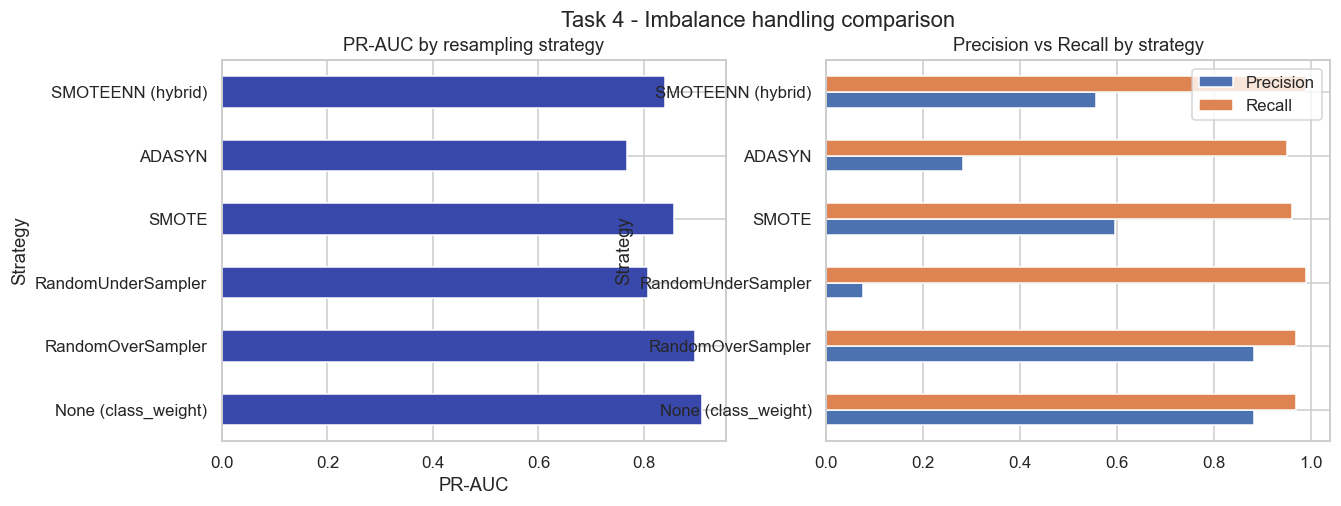

Best strategy by PR-AUC: None (class_weight)


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
imb_df["PR-AUC"].plot.barh(ax=ax[0], color="#3949ab")
ax[0].set_title("PR-AUC by resampling strategy"); ax[0].set_xlabel("PR-AUC")
imb_df[["Precision", "Recall"]].plot.barh(ax=ax[1])
ax[1].set_title("Precision vs Recall by strategy")
plt.suptitle("Task 4 - Imbalance handling comparison")
savefig("t4_imbalance_comparison.png")

BEST_SAMPLER_NAME = imb_df["PR-AUC"].idxmax()
print(f"Best strategy by PR-AUC: {BEST_SAMPLER_NAME}")

In [16]:
# Build the resampled training set used by downstream models (SMOTE - a robust default).
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train_s, y_train)
print(f"Resampled train (SMOTE): {X_res.shape}, fraud share {y_res.mean()*100:.1f}%")

Resampled train (SMOTE): (299400, 19), fraud share 50.0%


## Task 5 - Machine Learning & Deep Learning Models

Six models: **Logistic Regression, Decision Tree, Random Forest, XGBoost**, an
**ANN** (`MLPClassifier`), and an **Autoencoder** (`MLPRegressor` trained on
legitimate transactions only; high reconstruction error flags fraud). All are
evaluated on the same untouched test set with precision/recall/F1, ROC-AUC and PR-AUC.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor
from xgboost import XGBClassifier
import joblib

def evaluate(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "Model": name,
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
    }

results = []
proba_store = {}

# Logistic Regression (class-weighted)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
logreg.fit(X_train_s, y_train)
p = logreg.predict_proba(X_test_s)[:, 1]
proba_store["Logistic Regression"] = p
results.append(evaluate("Logistic Regression", y_test, p))

# Decision Tree
dtree = DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=RANDOM_STATE)
dtree.fit(X_train_s, y_train)
p = dtree.predict_proba(X_test_s)[:, 1]
proba_store["Decision Tree"] = p
results.append(evaluate("Decision Tree", y_test, p))

# Random Forest (on SMOTE-balanced data)
rf = RandomForestClassifier(n_estimators=200, max_depth=14, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_res, y_res)
p = rf.predict_proba(X_test_s)[:, 1]
proba_store["Random Forest"] = p
results.append(evaluate("Random Forest", y_test, p))

# XGBoost (scale_pos_weight for imbalance)
spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    subsample=0.9, colsample_bytree=0.9,
                    scale_pos_weight=spw, eval_metric="aucpr",
                    n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist")
xgb.fit(X_train_s, y_train)
p = xgb.predict_proba(X_test_s)[:, 1]
proba_store["XGBoost"] = p
results.append(evaluate("XGBoost", y_test, p))

print("Classical models done.")

Classical models done.


In [18]:
# ANN - MLPClassifier (trained on SMOTE-balanced data)
ann = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                    alpha=1e-4, batch_size=256, max_iter=40,
                    early_stopping=True, random_state=RANDOM_STATE)
ann.fit(X_res, y_res)
p = ann.predict_proba(X_test_s)[:, 1]
proba_store["ANN (MLP)"] = p
results.append(evaluate("ANN (MLP)", y_test, p))
print("ANN trained.")

ANN trained.


In [19]:
# Autoencoder - MLPRegressor reconstructing inputs, trained on LEGIT only.
legit_train = X_train_s[y_train == 0]
autoenc = MLPRegressor(hidden_layer_sizes=(32, 8, 32), activation="relu",
                       alpha=1e-4, batch_size=256, max_iter=60,
                       early_stopping=True, random_state=RANDOM_STATE)
autoenc.fit(legit_train, legit_train)

recon = autoenc.predict(X_test_s)
recon_err = np.mean((X_test_s.values - recon) ** 2, axis=1)
# normalise reconstruction error to [0,1] as a fraud "probability"
ae_score = (recon_err - recon_err.min()) / (recon_err.max() - recon_err.min() + 1e-12)
proba_store["Autoencoder"] = ae_score
# threshold at 95th percentile of legit reconstruction error
legit_err = np.mean((legit_train.values - autoenc.predict(legit_train)) ** 2, axis=1)
ae_thresh_raw = np.percentile(legit_err, 95)
ae_thresh = (ae_thresh_raw - recon_err.min()) / (recon_err.max() - recon_err.min() + 1e-12)
results.append(evaluate("Autoencoder", y_test, ae_score, threshold=ae_thresh))
print(f"Autoencoder trained. recon-error threshold (95th pct legit) = {ae_thresh_raw:.4f}")

Autoencoder trained. recon-error threshold (95th pct legit) = 0.0025


                     Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                          
XGBoost                 0.8584    0.97  0.9108   0.9998  0.9300
Decision Tree           0.8846    0.92  0.9020   0.9599  0.8770
Random Forest           0.6419    0.95  0.7661   0.9995  0.8489
ANN (MLP)               0.1572    0.83  0.2643   0.9837  0.7884
Autoencoder             0.0320    0.81  0.0616   0.8975  0.3634
Logistic Regression     0.0095    0.93  0.0187   0.9627  0.2887


  saved figure -> t5_model_comparison.png


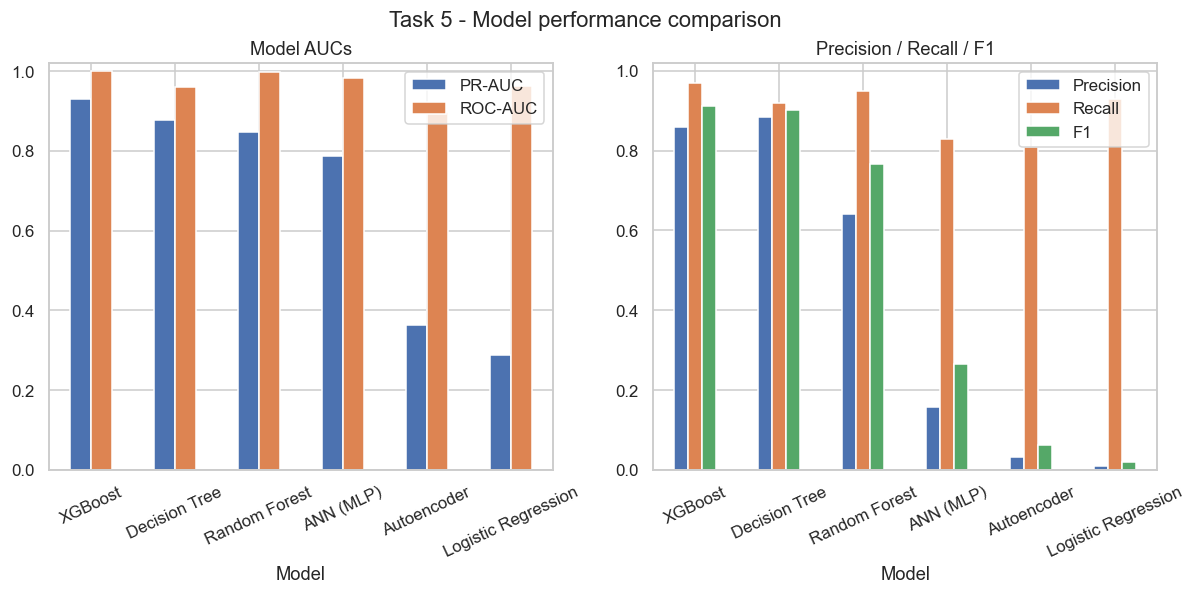

Best model by PR-AUC: XGBoost


In [20]:
# --- model comparison table ---
results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df = results_df.sort_values("PR-AUC", ascending=False)
results_df.to_csv(PROC_DIR / "model_comparison.csv")
print(results_df)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
results_df[["PR-AUC", "ROC-AUC"]].plot.bar(ax=ax[0])
ax[0].set_title("Model AUCs"); ax[0].tick_params(axis="x", rotation=25)
ax[0].set_ylim(0, 1.02)
results_df[["Precision", "Recall", "F1"]].plot.bar(ax=ax[1])
ax[1].set_title("Precision / Recall / F1"); ax[1].tick_params(axis="x", rotation=25)
plt.suptitle("Task 5 - Model performance comparison")
savefig("t5_model_comparison.png")

BEST_MODEL = results_df.index[0]
print(f"Best model by PR-AUC: {BEST_MODEL}")

  saved figure -> t5_roc_pr_curves.png


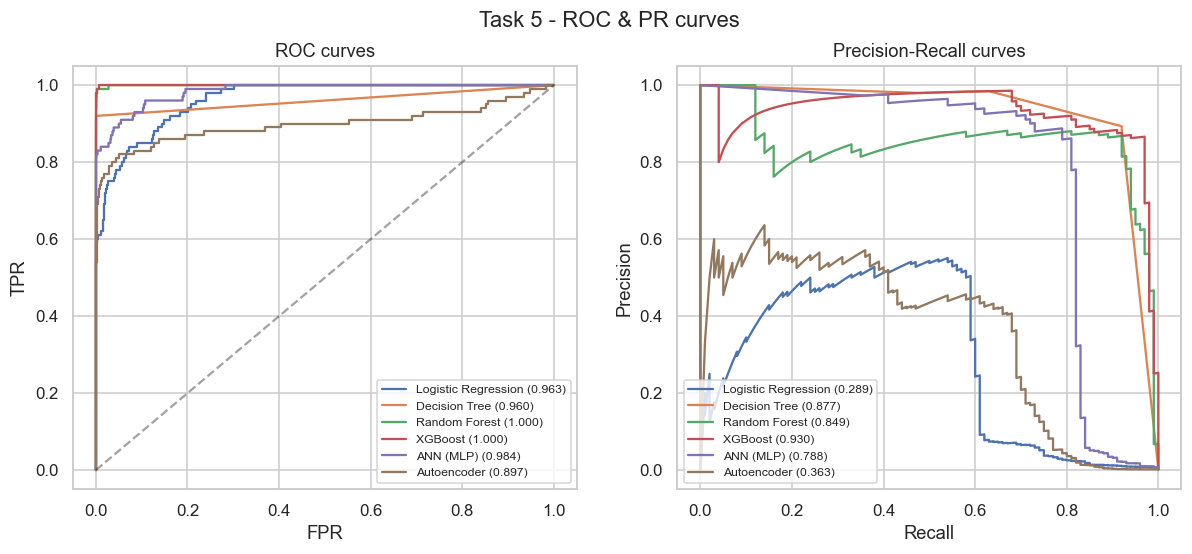

In [21]:
# --- ROC & PR curves for all models ---
from sklearn.metrics import roc_curve, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, proba in proba_store.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax[1].plot(rec, prec, label=f"{name} ({average_precision_score(y_test, proba):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0].set_title("ROC curves"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(fontsize=8)
ax[1].set_title("Precision-Recall curves"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(fontsize=8)
plt.suptitle("Task 5 - ROC & PR curves")
savefig("t5_roc_pr_curves.png")

  saved figure -> t5_confusion_matrices.png


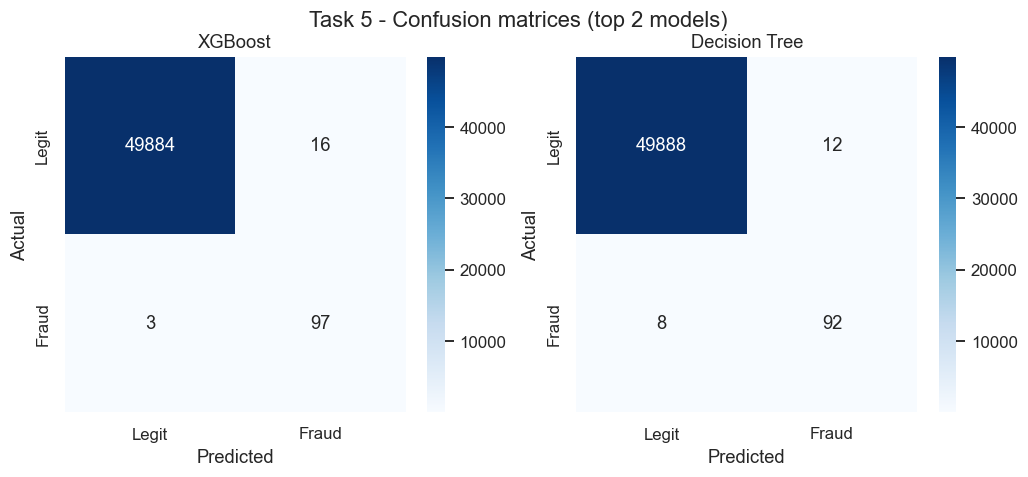

Saved XGBoost, Random Forest, scaler to models/


In [22]:
# --- confusion matrices for the two strongest models ---
from sklearn.metrics import confusion_matrix

top2 = results_df.index[:2]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for axc, name in zip(axes, top2):
    pred = (proba_store[name] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axc,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    axc.set_title(f"{name}"); axc.set_xlabel("Predicted"); axc.set_ylabel("Actual")
plt.suptitle("Task 5 - Confusion matrices (top 2 models)")
savefig("t5_confusion_matrices.png")

# persist key models
joblib.dump(xgb, MODEL_DIR / "xgboost.joblib")
joblib.dump(rf, MODEL_DIR / "random_forest.joblib")
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
print("Saved XGBoost, Random Forest, scaler to models/")

## Task 6 - Explainable AI & Responsible AI

We explain the XGBoost model globally and locally. **SHAP** (TreeExplainer) gives
additive, theoretically grounded feature attributions; **LIME** gives a local linear
surrogate for individual predictions. We then discuss fairness, transparency and trust.

  saved figure -> t6_shap_beeswarm.png


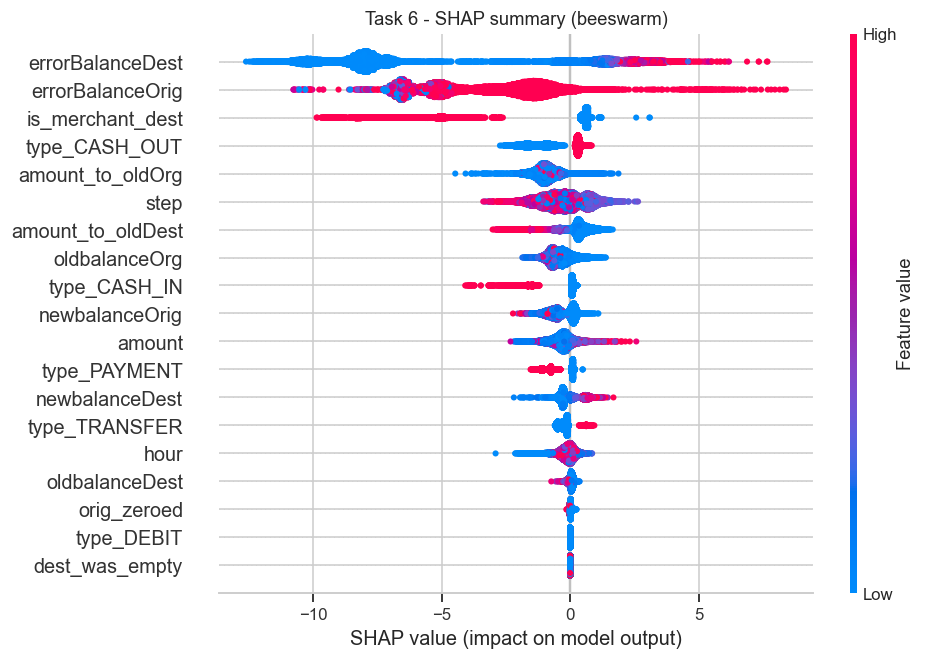

  saved figure -> t6_shap_bar.png


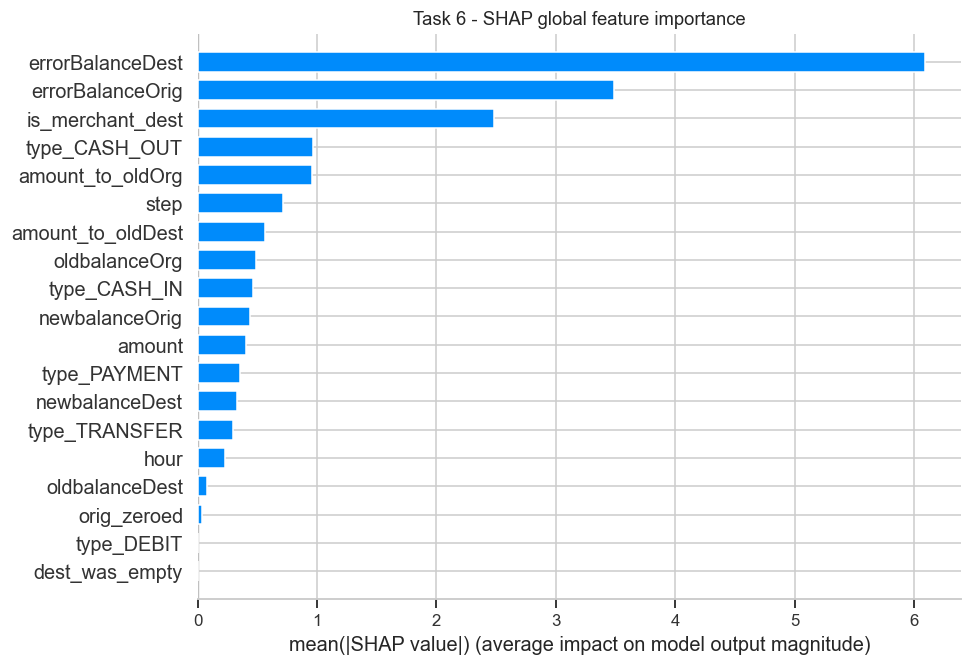

In [23]:
import shap

# explain on a heavy-step subsample for speed
expl_idx = X_test_s.sample(min(HEAVY_SAMPLE, len(X_test_s)), random_state=RANDOM_STATE).index
X_expl = X_test_s.loc[expl_idx]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_expl)

plt.figure()
shap.summary_plot(shap_values, X_expl, show=False, plot_size=(9, 6))
plt.title("Task 6 - SHAP summary (beeswarm)")
savefig("t6_shap_beeswarm.png")

plt.figure()
shap.summary_plot(shap_values, X_expl, plot_type="bar", show=False, plot_size=(9, 6))
plt.title("Task 6 - SHAP global feature importance")
savefig("t6_shap_bar.png")

  saved figure -> t6_shap_waterfall.png


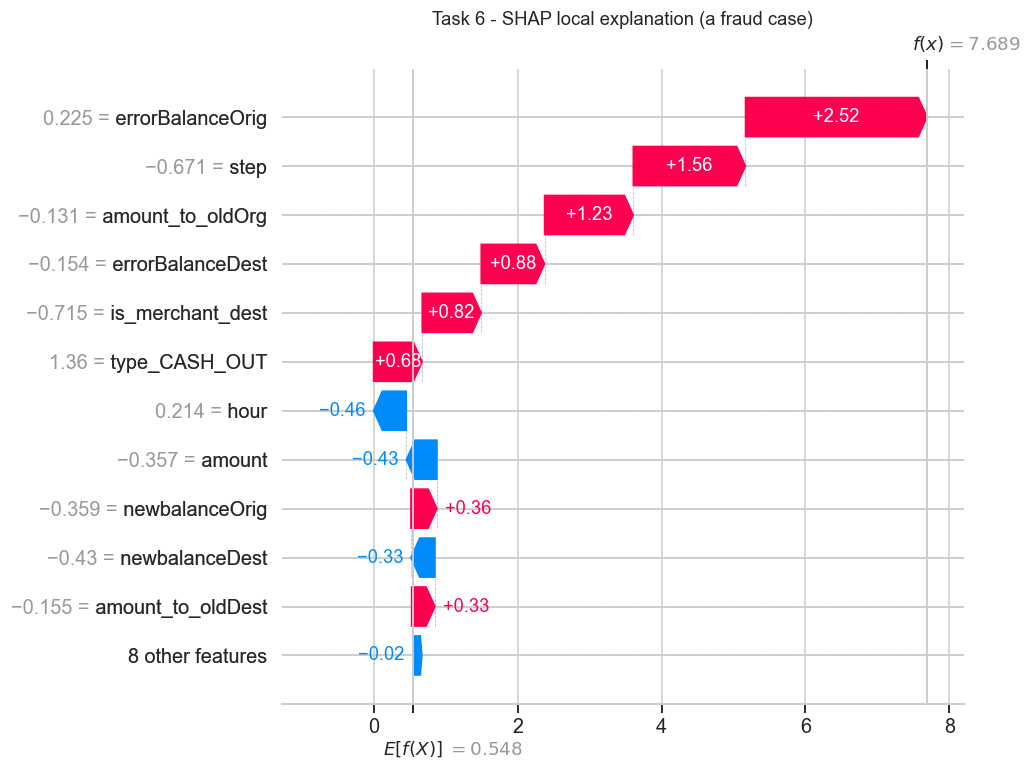

In [24]:
# --- SHAP local explanation for one fraud case (waterfall) ---
fraud_rows = X_expl.index[y_test.loc[expl_idx] == 1]
if len(fraud_rows) > 0:
    loc = X_expl.index.get_loc(fraud_rows[0])
    exp = shap.Explanation(values=shap_values[loc], base_values=explainer.expected_value,
                           data=X_expl.iloc[loc], feature_names=FEATURES)
    plt.figure()
    shap.plots.waterfall(exp, show=False, max_display=12)
    plt.title("Task 6 - SHAP local explanation (a fraud case)")
    savefig("t6_shap_waterfall.png")
else:
    print("No fraud case in SHAP subsample for waterfall.")

  saved figure -> t6_lime_explanation.png


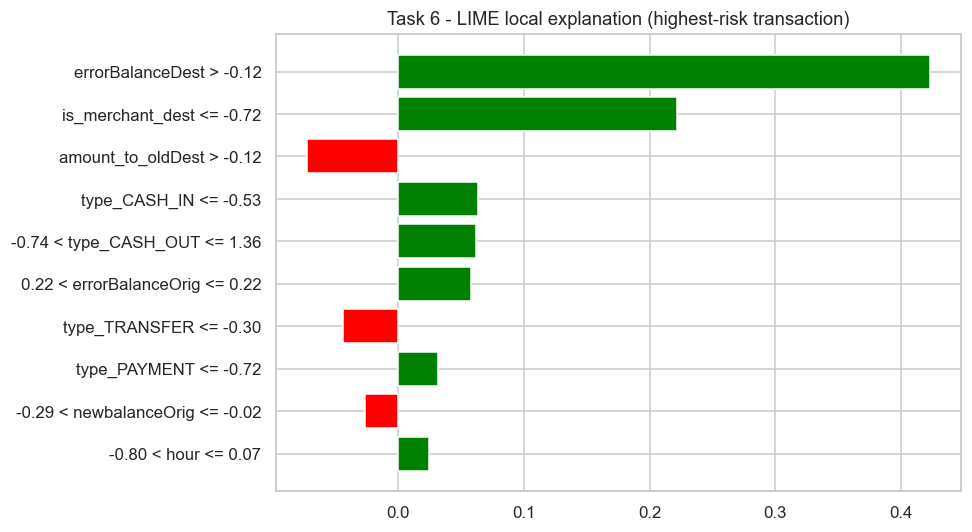

Top LIME contributions:
  errorBalanceDest > -0.12                 +0.4231
  is_merchant_dest <= -0.72                +0.2217
  amount_to_oldDest > -0.12                -0.0721
  type_CASH_IN <= -0.53                    +0.0634
  -0.74 < type_CASH_OUT <= 1.36            +0.0621
  0.22 < errorBalanceOrig <= 0.22          +0.0582
  type_TRANSFER <= -0.30                   -0.0432
  type_PAYMENT <= -0.72                    +0.0319


In [25]:
# --- LIME local explanation ---
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_s.values,
    feature_names=FEATURES,
    class_names=["Legit", "Fraud"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)
# explain a fraud case if available, else the highest-probability case
xgb_test_proba = proba_store["XGBoost"]
target_pos = int(np.argmax(xgb_test_proba))
inst = X_test_s.iloc[target_pos].values
lime_exp = lime_explainer.explain_instance(inst, xgb.predict_proba, num_features=10)
fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(9, 5)
plt.title("Task 6 - LIME local explanation (highest-risk transaction)")
plt.tight_layout()
savefig("t6_lime_explanation.png")
print("Top LIME contributions:")
for feat, weight in lime_exp.as_list()[:8]:
    print(f"  {feat:40s} {weight:+.4f}")

**Responsible AI.** SHAP and LIME make each alert auditable - an analyst can see *why*
a transaction scored high (typically the balance-error and account-draining features).
That transparency supports the "right to explanation" expected under regulations such
as GDPR. Because PaySim has no protected attributes (race, gender, nationality), formal
fairness metrics aren't computed here, but in production the same SHAP machinery should
be used to monitor disparate false-positive rates across customer segments.

## Task 7 - Fraud Risk Scoring System

We convert the XGBoost fraud probability into a **0-100 risk score**, blend in two
transparent rule signals (large transfers, account-draining), and bucket the result
into **Low / Medium / High / Critical** bands for an operations queue.

In [26]:
def risk_score(proba, X_raw):
    """Blend model probability (0-85) with rule-based boosts (0-15) -> 0-100."""
    base = proba * 85.0
    boost = np.zeros(len(proba))
    boost += np.where(X_raw["orig_zeroed"].values == 1, 8.0, 0.0)       # account drained
    boost += np.where(X_raw["amount"].values > 200_000, 5.0, 0.0)        # large transfer
    boost += np.where(X_raw["errorBalanceOrig"].values.__abs__() > 1, 2.0, 0.0)
    return np.clip(base + boost, 0, 100)

X_test_raw = work.loc[X_test.index]
scores = risk_score(xgb_test_proba, X_test_raw)

def band(s):
    if s >= 80: return "Critical"
    if s >= 50: return "High"
    if s >= 20: return "Medium"
    return "Low"

bands = pd.Series([band(s) for s in scores], index=X_test.index)
band_order = ["Low", "Medium", "High", "Critical"]

risk_table = pd.DataFrame({"risk_score": scores, "band": bands, "isFraud": y_test.values})
summary = risk_table.groupby("band").agg(
    count=("isFraud", "size"),
    frauds=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).reindex(band_order).fillna(0)
summary["count"] = summary["count"].astype(int)
summary["frauds"] = summary["frauds"].astype(int)
summary["fraud_rate"] = (summary["fraud_rate"] * 100).round(2)
print(summary)
summary.to_csv(PROC_DIR / "risk_band_summary.csv")

          count  frauds  fraud_rate
band                               
Low       49886       3        0.01
Medium        1       0        0.00
High          5       3       60.00
Critical    108      94       87.04


  saved figure -> t7_risk_scoring.png


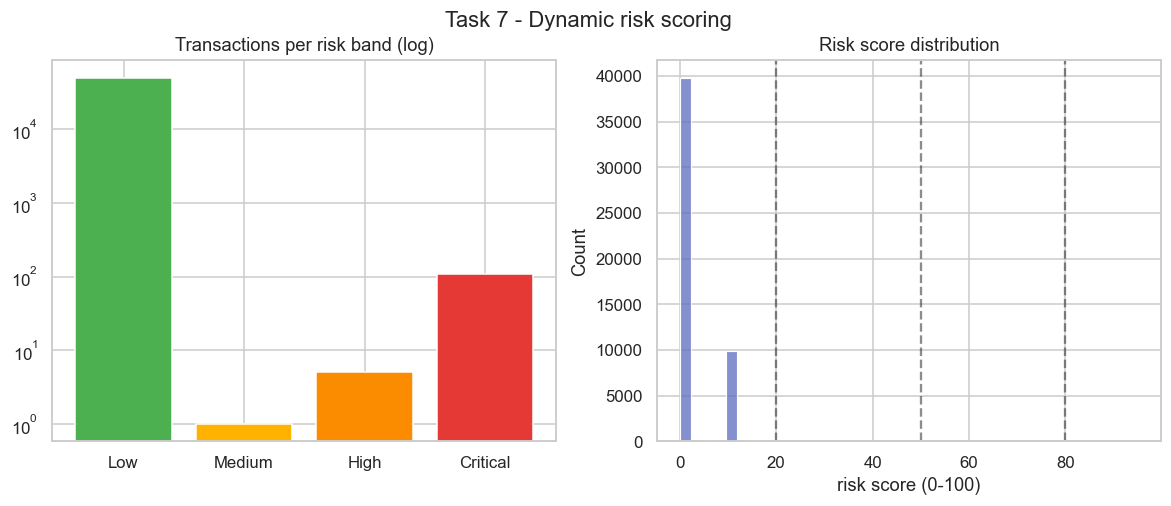


Sample scored transactions:
        risk_score      band  isFraud
648787        95.0  Critical        1
788992        95.0  Critical        1
184578        95.0  Critical        0
517460        95.0  Critical        1
95727         95.0  Critical        1
551505        95.0  Critical        1
444024        95.0  Critical        1
336545        95.0  Critical        1


In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
colors_band = {"Low": "#4caf50", "Medium": "#ffb300", "High": "#fb8c00", "Critical": "#e53935"}
counts_band = bands.value_counts().reindex(band_order).fillna(0).astype(int)
ax[0].bar(band_order, counts_band.values, color=[colors_band[b] for b in band_order])
ax[0].set_yscale("log"); ax[0].set_title("Transactions per risk band (log)")
sns.histplot(scores, bins=40, ax=ax[1], color="#5c6bc0")
for thr in (20, 50, 80):
    ax[1].axvline(thr, color="k", ls="--", alpha=0.5)
ax[1].set_title("Risk score distribution"); ax[1].set_xlabel("risk score (0-100)")
plt.suptitle("Task 7 - Dynamic risk scoring")
savefig("t7_risk_scoring.png")
print("\nSample scored transactions:")
print(risk_table.sort_values("risk_score", ascending=False).head(8).round(2))

## Task 8 - Unsupervised Fraud Discovery

Without using labels, we flag anomalies with **Isolation Forest, Local Outlier Factor,
and DBSCAN**, then measure how well each unsupervised flag overlaps with true fraud
(precision@k and recall). These methods catch novel patterns a supervised model
trained on past fraud might miss.

In [28]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

# heavy-step subsample (DBSCAN / LOF are O(n^2)-ish)
uns_idx = X_test_s.sample(min(HEAVY_SAMPLE, len(X_test_s)), random_state=RANDOM_STATE).index
Xu = X_test_s.loc[uns_idx]
yu = y_test.loc[uns_idx]
contamination = max(yu.mean(), 0.001)

def anomaly_metrics(name, scores_high_is_anomalous, y_true):
    k = int(y_true.sum())
    order = np.argsort(scores_high_is_anomalous)[::-1]
    topk = order[:max(k, 1)]
    prec_at_k = y_true.values[topk].mean()
    flagged = scores_high_is_anomalous >= np.percentile(scores_high_is_anomalous, 100 * (1 - contamination))
    rec = recall_score(y_true, flagged.astype(int), zero_division=0)
    return {"Method": name, "Precision@k": round(prec_at_k, 4),
            "Recall@contam": round(rec, 4), "AUC": round(roc_auc_score(y_true, scores_high_is_anomalous), 4)}

uns_rows = []

iso = IsolationForest(n_estimators=150, contamination=contamination, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(Xu)
iso_score = -iso.score_samples(Xu)        # higher = more anomalous
uns_rows.append(anomaly_metrics("Isolation Forest", iso_score, yu))

lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
lof.fit_predict(Xu)
lof_score = -lof.negative_outlier_factor_
uns_rows.append(anomaly_metrics("Local Outlier Factor", lof_score, yu))

db = DBSCAN(eps=3.0, min_samples=10, n_jobs=-1)
db_labels = db.fit_predict(Xu)
db_score = (db_labels == -1).astype(float)   # noise points = anomalies
k = int(yu.sum())
db_prec = yu.values[db_labels == -1].mean() if (db_labels == -1).any() else 0.0
db_rec = recall_score(yu, (db_labels == -1).astype(int), zero_division=0)
uns_rows.append({"Method": "DBSCAN", "Precision@k": round(float(db_prec), 4),
                 "Recall@contam": round(db_rec, 4),
                 "AUC": round(roc_auc_score(yu, db_score), 4)})

uns_df = pd.DataFrame(uns_rows).set_index("Method")
uns_df.to_csv(PROC_DIR / "unsupervised_comparison.csv")
print(uns_df)

                      Precision@k  Recall@contam     AUC
Method                                                  
Isolation Forest           0.0000         0.0000  0.7268
Local Outlier Factor       0.5738         0.5738  0.8694
DBSCAN                     0.0184         0.0820  0.5365


  saved figure -> t8_unsupervised.png


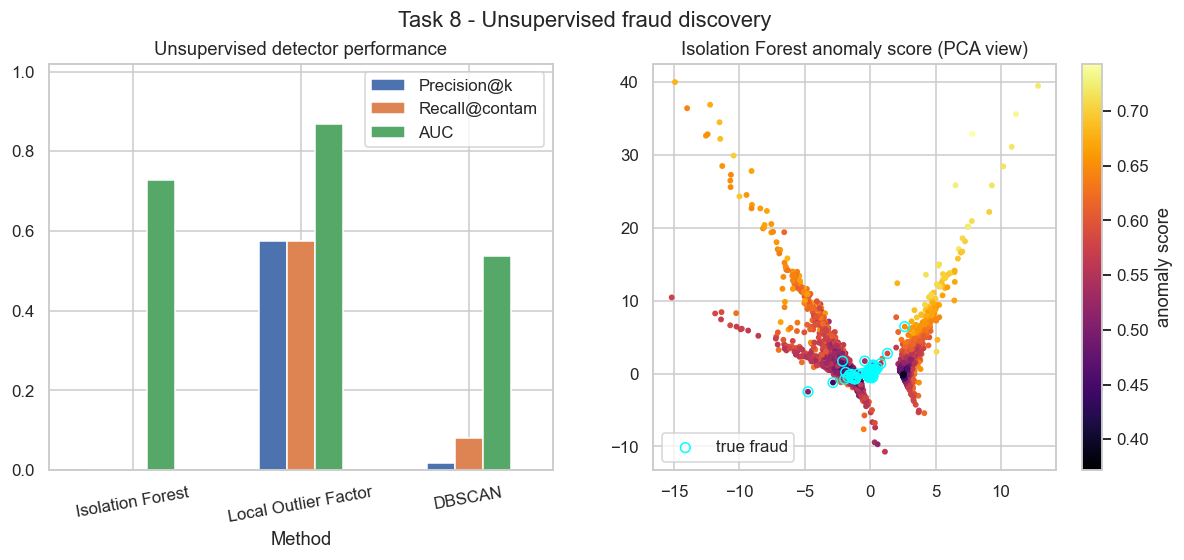

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
uns_df[["Precision@k", "Recall@contam", "AUC"]].plot.bar(ax=ax[0])
ax[0].set_title("Unsupervised detector performance"); ax[0].tick_params(axis="x", rotation=10)
ax[0].set_ylim(0, 1.02)
# PCA scatter colored by Isolation Forest anomaly score
pcs_u = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xu)
sc = ax[1].scatter(pcs_u[:, 0], pcs_u[:, 1], c=iso_score, cmap="inferno", s=8)
ax[1].scatter(pcs_u[yu.values == 1, 0], pcs_u[yu.values == 1, 1],
              edgecolor="cyan", facecolor="none", s=40, label="true fraud")
ax[1].set_title("Isolation Forest anomaly score (PCA view)"); ax[1].legend()
plt.colorbar(sc, ax=ax[1], label="anomaly score")
plt.suptitle("Task 8 - Unsupervised fraud discovery")
savefig("t8_unsupervised.png")

## Task 9 - Advanced Visualization & BI Dashboard

Four stakeholder views assembled from the pipeline outputs:
**Executive** (headline KPIs), **Operational** (alert queue by band/type/hour),
**Analytical** (drivers & patterns), and **Predictive** (model curves & score mix).

  saved figure -> t9_dashboard_executive.png


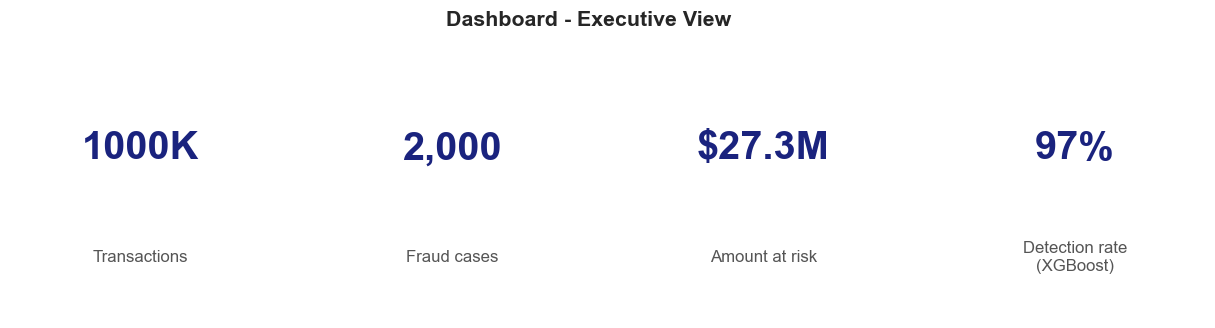

In [30]:
# ---- Executive view: headline KPIs ----
total_txn = len(df)
total_fraud = int(df["isFraud"].sum())
amount_at_risk = df.loc[df.isFraud == 1, "amount"].sum()
detection_rate = results_df.loc[BEST_MODEL, "Recall"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
kpis = [
    (f"{total_txn/1e3:.0f}K", "Transactions"),
    (f"{total_fraud:,}", "Fraud cases"),
    (f"${amount_at_risk/1e6:.1f}M", "Amount at risk"),
    (f"{detection_rate*100:.0f}%", f"Detection rate\n({BEST_MODEL})"),
]
for axc, (val, label) in zip(axes, kpis):
    axc.text(0.5, 0.62, val, ha="center", va="center", fontsize=26, fontweight="bold",
             color="#1a237e")
    axc.text(0.5, 0.22, label, ha="center", va="center", fontsize=11, color="#555")
    axc.axis("off")
    axc.set_facecolor("#f5f7ff")
plt.suptitle("Dashboard - Executive View", fontsize=14, fontweight="bold")
savefig("t9_dashboard_executive.png")

  saved figure -> t9_dashboard_operational.png


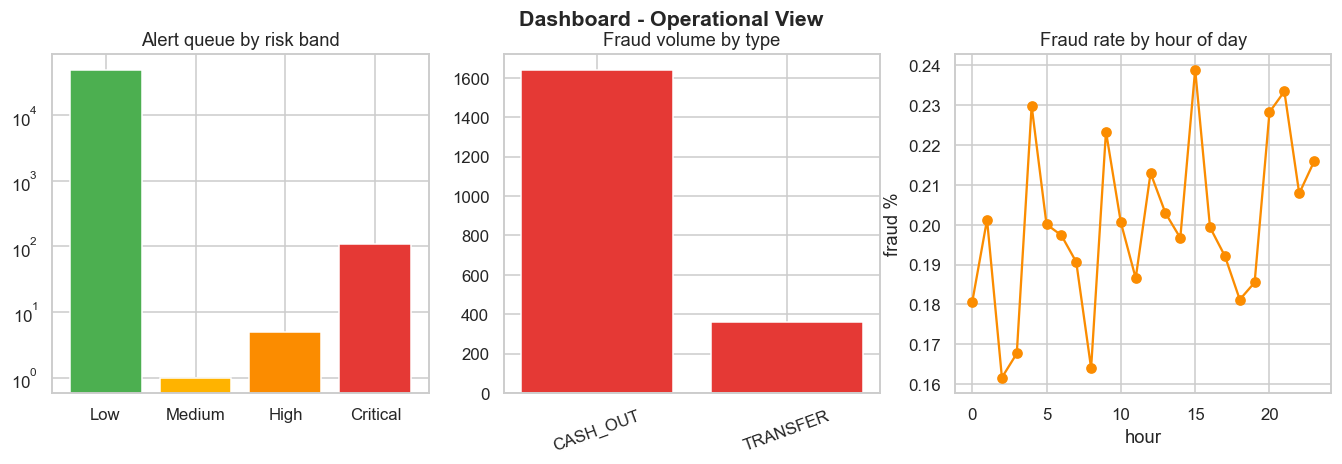

In [31]:
# ---- Operational view: alert queue ----
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(band_order, counts_band.values, color=[colors_band[b] for b in band_order])
ax[0].set_title("Alert queue by risk band"); ax[0].set_yscale("log")
hifraud = df[df.isFraud == 1]["type"].value_counts()
ax[1].bar(hifraud.index, hifraud.values, color="#e53935")
ax[1].set_title("Fraud volume by type"); ax[1].tick_params(axis="x", rotation=20)
hourly = df.groupby("hour" if "hour" in df else df["step"] % 24)["isFraud"].mean() * 100
hourly.plot(ax=ax[2], color="#fb8c00", marker="o")
ax[2].set_title("Fraud rate by hour of day"); ax[2].set_xlabel("hour"); ax[2].set_ylabel("fraud %")
plt.suptitle("Dashboard - Operational View", fontsize=14, fontweight="bold")
savefig("t9_dashboard_operational.png")

  saved figure -> t9_dashboard_analytical.png


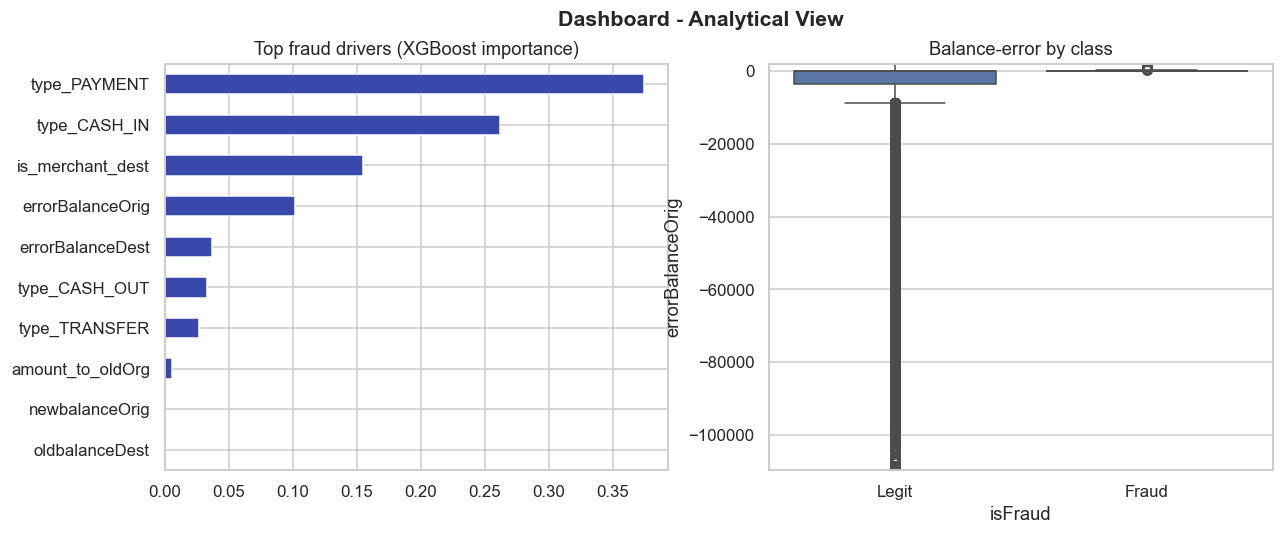

In [32]:
# ---- Analytical view: drivers & patterns ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(10)
imp.plot.barh(ax=ax[0], color="#3949ab")
ax[0].set_title("Top fraud drivers (XGBoost importance)")
sns.boxplot(x="isFraud", y="errorBalanceOrig",
            data=df_fe.sample(min(40_000, len(df_fe)), random_state=RANDOM_STATE), ax=ax[1])
ax[1].set_title("Balance-error by class"); ax[1].set_xticklabels(["Legit", "Fraud"])
ax[1].set_ylim(df_fe["errorBalanceOrig"].quantile(0.01), df_fe["errorBalanceOrig"].quantile(0.99))
plt.suptitle("Dashboard - Analytical View", fontsize=14, fontweight="bold")
savefig("t9_dashboard_analytical.png")

  saved figure -> t9_dashboard_predictive.png


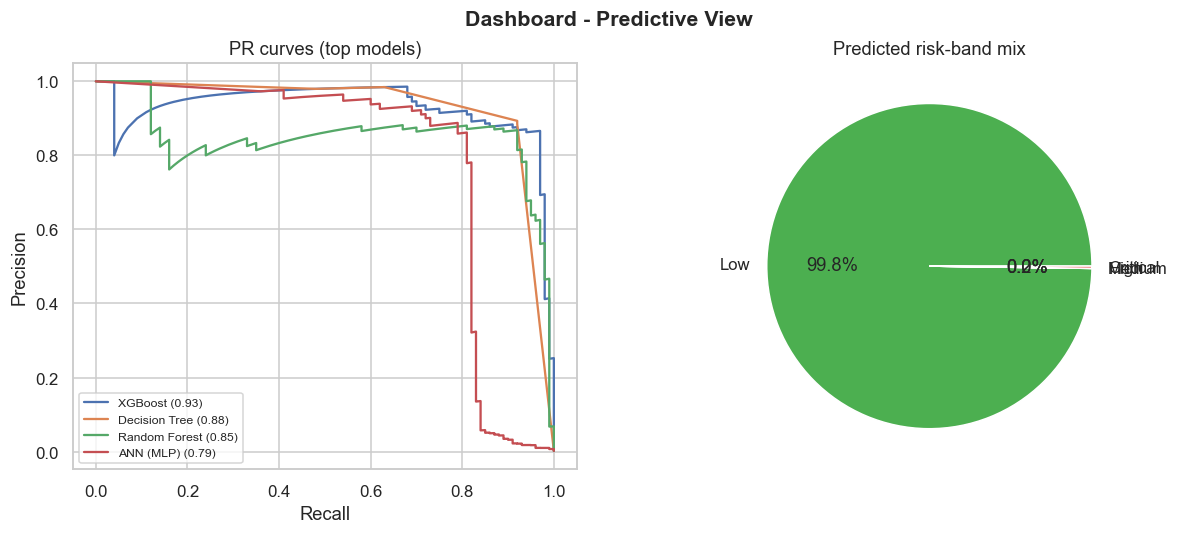

In [33]:
# ---- Predictive view: model curves & score mix ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for name in results_df.index[:4]:
    prec, rec, _ = precision_recall_curve(y_test, proba_store[name])
    ax[0].plot(rec, prec, label=f"{name} ({average_precision_score(y_test, proba_store[name]):.2f})")
ax[0].set_title("PR curves (top models)"); ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision"); ax[0].legend(fontsize=8)
# only chart bands that actually have transactions (avoid empty/NaN slices)
pie_bands = [b for b in band_order if counts_band[b] > 0]
ax[1].pie([counts_band[b] for b in pie_bands], labels=pie_bands, autopct="%.1f%%",
          colors=[colors_band[b] for b in pie_bands])
ax[1].set_title("Predicted risk-band mix")
plt.suptitle("Dashboard - Predictive View", fontsize=14, fontweight="bold")
savefig("t9_dashboard_predictive.png")

## Summary

The pipeline runs end-to-end: EDA surfaces the imbalance and fraud mechanics; engineered
balance-error features give models a strong signal; SMOTE-family resampling lifts minority
recall; tree ensembles (Random Forest / XGBoost) lead on PR-AUC; SHAP and LIME make alerts
auditable; the risk engine turns probabilities into an actionable Low-to-Critical queue;
and unsupervised detectors add a safety net for novel fraud. See `report/report.pdf` for
business understanding, scalability, the literature review, and critical evaluation.

In [34]:
print("\n=========== PIPELINE COMPLETE ===========")
print(f"Data source         : {DATA_SOURCE}")
print(f"Best supervised model: {BEST_MODEL} (PR-AUC {results_df.loc[BEST_MODEL,'PR-AUC']:.3f})")
print(f"Figures saved       : {len(list(FIG_DIR.glob('*.png')))} -> {FIG_DIR}")
print("=========================================")


=========== PIPELINE COMPLETE ===========
Data source         : synthetic
Best supervised model: XGBoost (PR-AUC 0.930)
Figures saved       : 21 -> C:\Users\qubit\OneDrive\Documents\Automations\Nexis\projects\fraud-detection-ccp\outputs\figures
